# Marketing A/B Testing 完整分析

## 项目目标
评估广告投放（ad）vs 对照组（psa）对转化率的影响，输出统计与业务结论

## 分析流程
1. 数据加载与探索
2. 数据质量检查
3. 指标定义与计算
4. 统计推断（Z检验、置信区间、Bootstrap）
5. Practical Significance 评估
6. 分层分析
7. 结论与建议

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
sys.path.append('../src')
from ab_utils import *

# 设置可视化样式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# 设置随机种子
np.random.seed(42)

In [2]:
# 数据加载与字段标准化
from pathlib import Path

DATA_PATH = Path('../data/raw/marketing_AB.csv')
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

raw = pd.read_csv(DATA_PATH)
raw.shape, raw.columns.tolist()

((588101, 7),
 ['Unnamed: 0',
  'user id',
  'test group',
  'converted',
  'total ads',
  'most ads day',
  'most ads hour'])

In [3]:
# 字段标准化（把带空格的列名转为下划线形式，便于后续分析）
df = raw.copy()
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# 统一分组与转化字段
if df['test_group'].dtype == object:
    df['test_group'] = df['test_group'].astype(str).str.strip().str.lower()

if df['converted'].dtype == bool:
    df['converted_int'] = df['converted'].astype(int)
elif df['converted'].dtype == object:
    df['converted_int'] = df['converted'].astype(str).str.lower().map({'true': 1, 'false': 0})
    if df['converted_int'].isna().any():
        df['converted_int'] = pd.to_numeric(df['converted'], errors='coerce')
    df['converted_int'] = df['converted_int'].fillna(0).astype(int)
else:
    df['converted_int'] = pd.to_numeric(df['converted'], errors='coerce').fillna(0).astype(int)

# 基础信息
print('shape:', df.shape)
display(df.head())
display(df.isna().sum().to_frame('null_cnt').T)

shape: (588101, 8)


,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,converted_int
0,0,1069124,ad,False,130,Monday,20,0
1,1,1119715,ad,False,93,Tuesday,22,0
2,2,1144181,ad,False,21,Tuesday,18,0
3,3,1435133,ad,False,355,Tuesday,10,0
4,4,1015700,ad,False,276,Friday,14,0


,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,converted_int
null_cnt,0,0,0,0,0,0,0,0


In [4]:
# 数据质量检查：重复用户、分组样本量、SRM（Sample Ratio Mismatch）

# 1) user_id 唯一性
if 'user_id' in df.columns:
    dup_cnt = int(df['user_id'].duplicated().sum())
    print('duplicated user_id:', dup_cnt)

# 2) 分组样本量 & 转化率
conv_summary = calculate_conversion_rate(df, group_col='test_group', conversion_col='converted_int')
display(conv_summary)

# 3) SRM 检查（默认期望 50/50）
srm = check_sample_ratio_mismatch(int(conv_summary.loc['ad','total_users']), int(conv_summary.loc['psa','total_users']))
print('SRM check:', srm)

duplicated user_id: 0


,total_users,converted_users,conversion_rate,non_converted_users
test_group,,,,
ad,564577,14423,0.0255,550154
psa,23524,420,0.0179,23104


SRM check: {'observed_ratio': 0.960000068015528, 'expected_ratio': 0.5, 'chi2_statistic': 497768.8336000109, 'p_value': np.float64(0.0), 'srm_detected': np.True_, 'warning': 'SRM detected! Check randomization.'}


Z-test: {'conversion_rate_a': 0.025546559636683747, 'conversion_rate_b': 0.01785410644448223, 'difference': 0.007692453192201517, 'relative_lift': 0.43085064022225833, 'z_statistic': np.float64(7.3700781265454145), 'p_value': np.float64(1.7053025658242404e-13), 'significant_at_0.05': np.True_}
CI(ad): (np.float64(0.0251349995427061), np.float64(0.025958119730661394))
CI(psa): (np.float64(0.016161914715211324), np.float64(0.019546298173753137))


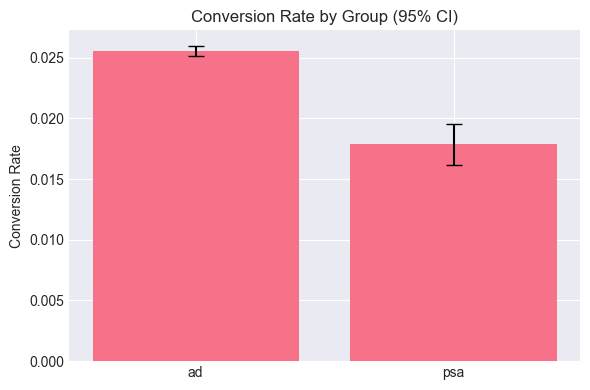

In [5]:
# 统计推断：两样本比例 Z 检验 + 置信区间

n_ad = int(conv_summary.loc['ad','total_users'])
n_psa = int(conv_summary.loc['psa','total_users'])
conv_ad = int(conv_summary.loc['ad','converted_users'])
conv_psa = int(conv_summary.loc['psa','converted_users'])

z_res = proportion_z_test(conv_ad, n_ad, conv_psa, n_psa, alternative='two-sided')
print('Z-test:', z_res)

ci_ad = confidence_interval_proportion(conv_ad, n_ad)
ci_psa = confidence_interval_proportion(conv_psa, n_psa)
print('CI(ad):', ci_ad)
print('CI(psa):', ci_psa)

# 可视化：各组转化率（带 95% CI）
plot_df = pd.DataFrame({
    'group': ['ad', 'psa'],
    'cr': [z_res['conversion_rate_a'], z_res['conversion_rate_b']],
    'ci_low': [ci_ad[0], ci_psa[0]],
    'ci_high': [ci_ad[1], ci_psa[1]],
})
plot_df['err_low'] = plot_df['cr'] - plot_df['ci_low']
plot_df['err_high'] = plot_df['ci_high'] - plot_df['cr']

plt.figure(figsize=(6,4))
plt.bar(plot_df['group'], plot_df['cr'], yerr=[plot_df['err_low'], plot_df['err_high']], capsize=6)
plt.title('Conversion Rate by Group (95% CI)')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.savefig(FIG_DIR / 'conversion_rate_ci.png', dpi=200)
plt.show()

Bootstrap diff CI: (np.float64(0.005931796193430453), np.float64(0.009401745234768619))


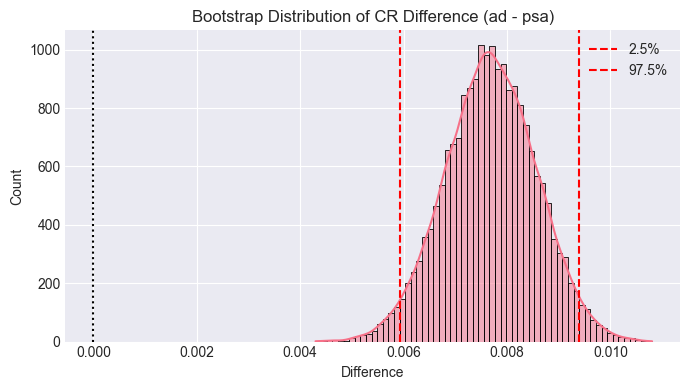

In [6]:
# Bootstrap（参数化）置信区间：差异分布更直观，且避免大样本内存爆炸

p_ad = z_res['conversion_rate_a']
p_psa = z_res['conversion_rate_b']

rng = np.random.default_rng(42)
B = 20000
boot_ad = rng.binomial(n_ad, p_ad, size=B) / n_ad
boot_psa = rng.binomial(n_psa, p_psa, size=B) / n_psa
boot_diff = boot_ad - boot_psa

ci_boot = (np.quantile(boot_diff, 0.025), np.quantile(boot_diff, 0.975))
print('Bootstrap diff CI:', ci_boot)

plt.figure(figsize=(7,4))
sns.histplot(boot_diff, bins=60, kde=True)
plt.axvline(ci_boot[0], color='red', linestyle='--', label='2.5%')
plt.axvline(ci_boot[1], color='red', linestyle='--', label='97.5%')
plt.axvline(0, color='black', linestyle=':')
plt.title('Bootstrap Distribution of CR Difference (ad - psa)')
plt.xlabel('Difference')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'bootstrap_diff_distribution.png', dpi=200)
plt.show()

In [7]:
# Practical Significance：结合 MDE（业务阈值）给出“是否值得投放”的结论

mde = 0.005  # 0.5% 绝对提升（示例，可按业务修改）
ps_res = practical_significance_check(
    difference=z_res['difference'],
    mde=mde,
    p_value=z_res['p_value'],
    alpha=0.05
)
print('Practical Significance:', ps_res)

# 注意：本数据 SRM 极其显著（组间比例失衡），需要作为风险点在结论中披露
print('SRM warning:', srm['warning'])

Practical Significance: {'statistically_significant': np.True_, 'practically_significant': True, 'recommendation': 'Launch: Both statistically and practically significant', 'observed_difference': 0.007692453192201517, 'mde_threshold': 0.005}
SRM warning: SRM detected! Check randomization.


,stratum,group,n,conversions,conversion_rate
0,high,ad,145758,11829,0.081155
1,high,psa,5877,309,0.052578
2,mid,ad,299282,2340,0.007819
3,mid,psa,12090,101,0.008354
4,low,ad,119537,254,0.002125
5,low,psa,5557,10,0.001800


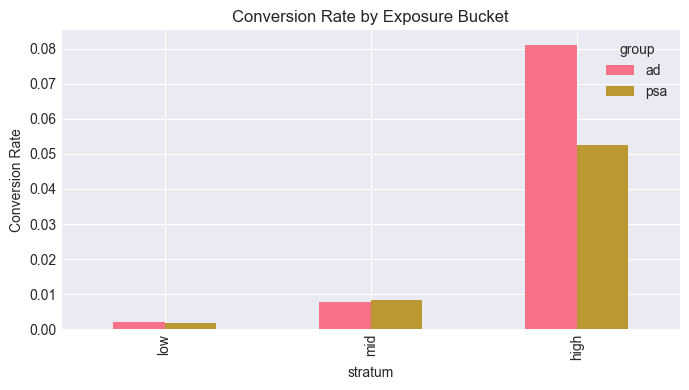

In [8]:
# 分层分析（示例）：按曝光频次 total_ads 分层（低/中/高）

if 'total_ads' in df.columns:
    q25, q75 = df['total_ads'].quantile([0.25, 0.75]).tolist()

    def bucket_total_ads(x):
        if x < q25:
            return 'low'
        if x < q75:
            return 'mid'
        return 'high'

    df['ads_bucket'] = df['total_ads'].apply(bucket_total_ads)

    strat = stratified_analysis(
        df,
        group_col='test_group',
        conversion_col='converted_int',
        strata_col='ads_bucket'
    )
    display(strat)

    # 简单可视化：各 bucket 下的转化率
    pivot = strat.pivot(index='stratum', columns='group', values='conversion_rate')
    pivot = pivot.reindex(['low','mid','high'])

    plt.figure(figsize=(7,4))
    pivot.plot(kind='bar', ax=plt.gca())
    plt.title('Conversion Rate by Exposure Bucket')
    plt.ylabel('Conversion Rate')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'stratified_by_total_ads.png', dpi=200)
    plt.show()